   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.2/3.2 MB 31.0 MB/s eta 0:00:00


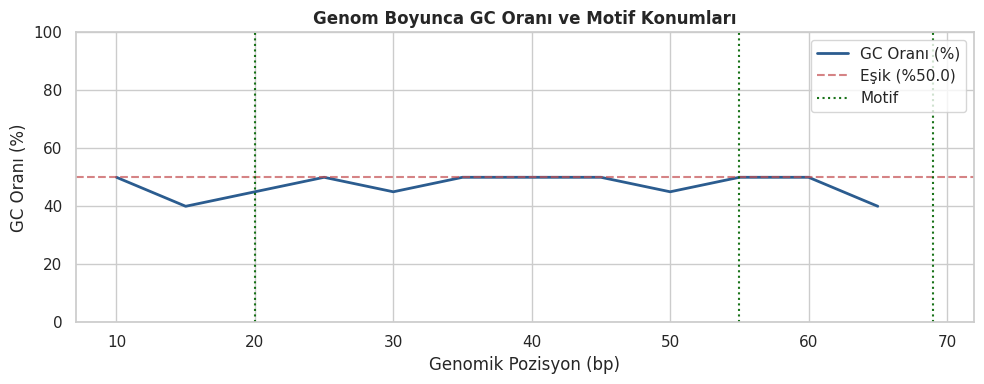

In [ ]:
!pip install biopython
import matplotlib.pyplot as plt
import seaborn as sns

# --- 1. GC HESAPLAMA FONKSİYONU ---
def calculate_gc_content(sequence: str) -> float:
    if not sequence:
        return 0.0
    seq_upper = sequence.upper()
    g_count = seq_upper.count('G')
    c_count = seq_upper.count('C')
    return round(((g_count + c_count) / len(seq_upper)) * 100, 2)

# --- 2. SLIDING WINDOW FONKSİYONU ---
def sliding_window_gc(sequence: str, window_size: int = 30, step: int = 10) -> list:
    results = []
    seq_len = len(sequence)
    for start in range(0, seq_len - window_size + 1, step):
        end = start + window_size
        gc_val = calculate_gc_content(sequence[start:end])
        results.append((start, end, gc_val))
    return results

# --- 3. MOTİF ARAMA FONKSİYONU ---
def find_motifs_with_find(sequence: str, motif: str) -> list:
    positions = []
    seq_upper = sequence.upper()
    motif_upper = motif.upper()
    start_pos = 0
    while True:
        pos = seq_upper.find(motif_upper, start_pos)
        if pos == -1:
            break
        positions.append(pos)
        start_pos = pos + 1
    return positions

# --- 4. GÖRSELLEŞTİRME FONKSİYONU ---
def plot_gc_content(window_results: list, motif_indices: list = None, target_gc: float = 50.0):
    positions = [(start + end) / 2 for start, end, _ in window_results]
    gc_values = [gc for _, _, gc in window_results]

    sns.set_theme(style="whitegrid")
    plt.figure(figsize=(10, 4))

    # GC Çizgisi
    plt.plot(positions, gc_values, color='#2b5c8f', linewidth=2, label='GC Oranı (%)')
    # Eşik Çizgisi
    plt.axhline(y=target_gc, color='r', linestyle='--', alpha=0.7, label=f'Eşik (%{target_gc})')

    # Motif Konumları
    if motif_indices:
        for idx in motif_indices:
            plt.axvline(x=idx, color='darkgreen', alpha=0.9, linestyle=':', label='Motif' if idx == motif_indices[0] else "")

    plt.title("Genom Boyunca GC Oranı ve Motif Konumları", fontsize=12, fontweight='bold')
    plt.xlabel("Genomik Pozisyon (bp)")
    plt.ylabel("GC Oranı (%)")
    plt.ylim(0, 100)
    plt.legend(loc='upper right')
    plt.tight_layout()


    plt.show()

# Örnek Sentetik DNA Dizisi
test_dna = "ATGCGATCGATCGATCGATCGAATTCGATCGATCGATCGATCGATCGATCGATCGGAATTCGATCGATCGAATTCGATC"
target_motif = "GAATTC"  # EcoRI kesim sitesi


windows = sliding_window_gc(test_dna, window_size=20, step=5)
motifs = find_motifs_with_find(test_dna, target_motif)
plot_gc_content(windows, motifs, target_gc=50.0)